In [1]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import numpy as np
import os
import glob
import awkward as ak
import boost_histogram as bh
import mplhep
from matplotlib.colors import LogNorm
# !pip install pyarrow
# !pip install "pyarrow<21" --break-system-packages

In [2]:
runs_F222 = [7733, 8712]
runs_F223 = [8713, 9188]

runs_F231 = [10555, 11470]
runs_F232 = [11470, 11703]

runs_F241 = [14399, 15026]
runs_tungsten = [15030, 15594]
runs_F242 = [15652, 15820]
runs_caloNu = [15821, 16924]
runs_F243 = [16928, 17230]

runs_2022 = [8025, 9188]
runs_2023 = [10604, 11703]
runs_2024_preCaloNu = [14399, 15821]
runs_2024_CaloNu = [15821, 16924]
runs_2024_afterCaloNu = [16928, 17230]

In [3]:
files_F222 = []
files_F223 = []
files_F231 = []
files_F232 = []
files_F241 = []
files_tungsten = []
files_F242 = []
files_caloNu = []
files_F243 = []

data_files = glob.glob("AnalysisZipFramework/submission/analysis_output/*.root")
for file in data_files:
    run_num = int(os.path.basename(file).split('.')[0])
    if runs_F222[0] <= run_num <= runs_F222[1]:
        files_F222.append(file)
    elif runs_F223[0] <= run_num <= runs_F223[1]:
        files_F223.append(file)
    elif runs_F231[0] <= run_num <= runs_F231[1]:
        files_F231.append(file)
    elif runs_F232[0] <= run_num <= runs_F232[1]:
        files_F232.append(file)
    elif runs_F241[0] <= run_num <= runs_F241[1]:
        files_F241.append(file)
    elif runs_tungsten[0] <= run_num <= runs_tungsten[1]:
        files_tungsten.append(file)
    elif runs_F242[0] <= run_num <= runs_F242[1]:
        files_F242.append(file)
    elif runs_caloNu[0] <= run_num <= runs_caloNu[1]:
        files_caloNu.append(file)
    elif runs_F243[0] <= run_num <= runs_F243[1]:
        files_F243.append(file)

print(f"Files for F222: {len(files_F222)}")
print(f"Files for F223: {len(files_F223)}")
print(f"Files for F231: {len(files_F231)}")
print(f"Files for F232: {len(files_F232)}")
print(f"Files for F241: {len(files_F241)}")
print(f"Files for tungsten: {len(files_tungsten)}")
print(f"Files for F242: {len(files_F242)}")
print(f"Files for caloNu: {len(files_caloNu)}")
print(f"Files for F243: {len(files_F243)}")

Files for F222: 95
Files for F223: 83
Files for F231: 61
Files for F232: 28
Files for F241: 49
Files for tungsten: 43
Files for F242: 31
Files for caloNu: 130
Files for F243: 23


In [4]:
def parse_grl_csv(file_path):
    grl_df = pd.read_csv(file_path)
    return grl_df

grl_2022_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2022_physics.csv")
grl_2023_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2023_physics.csv")
grl_2024_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2024_physics.csv")
grl_df = pd.concat([grl_2022_df, grl_2023_df, grl_2024_df], ignore_index=True)

In [5]:
lumi_F222 = grl_df[grl_df["Run"].between(runs_F222[0], runs_F222[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1
lumi_F223 = grl_df[grl_df["Run"].between(runs_F223[0], runs_F223[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1
lumi_F231 = grl_df[grl_df["Run"].between(runs_F231[0], runs_F231[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1
lumi_F232 = grl_df[grl_df["Run"].between(runs_F232[0], runs_F232[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1

lumi_F241 = grl_df[grl_df["Run"].between(runs_F241[0], runs_F241[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1
lumi_tungsten = grl_df[grl_df["Run"].between(runs_tungsten[0], runs_tungsten[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1
lumi_F242 = grl_df[grl_df["Run"].between(runs_F242[0], runs_F242[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1
lumi_caloNu = grl_df[grl_df["Run"].between(runs_caloNu[0], runs_caloNu[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1
lumi_F243 = grl_df[grl_df["Run"].between(runs_F243[0], runs_F243[1], inclusive="both")][" LumiRec"].sum() / 1000  # Convert to fb^-1

print(f"Luminosity for F222: {lumi_F222:.3f} fb^-1")
print(f"Luminosity for F223: {lumi_F223:.3f} fb^-1")
print(f"Luminosity for F231: {lumi_F231:.3f} fb^-1")
print(f"Luminosity for F232: {lumi_F232:.3f} fb^-1")
print(f"Luminosity for F241: {lumi_F241:.3f} fb^-1")
print(f"Luminosity for tungsten: {lumi_tungsten:.3f} fb^-1")
print(f"Luminosity for F242: {lumi_F242:.3f} fb^-1")
print(f"Luminosity for caloNu: {lumi_caloNu:.3f} fb^-1")
print(f"Luminosity for F243: {lumi_F243:.3f} fb^-1")

Luminosity for F222: 9.700 fb^-1
Luminosity for F223: 27.289 fb^-1
Luminosity for F231: 20.473 fb^-1
Luminosity for F232: 9.225 fb^-1
Luminosity for F241: 11.522 fb^-1
Luminosity for tungsten: 17.449 fb^-1
Luminosity for F242: 9.772 fb^-1
Luminosity for caloNu: 70.033 fb^-1
Luminosity for F243: 11.354 fb^-1


In [6]:
file_2022_2023_MC = "build/MC_no_truth_cuts_fixed_ENFB8/2022_2023.bck.root"
file_2024_noCaloNu_MC = "build/MC_no_truth_cuts_fixed_ENFB8/2024_noCaloNu.bck.root"
file_2024_withCaloNu_MC = "build/MC_no_truth_cuts_fixed_ENFB8/2024_CaloNu.bck.root"

file_2022_2023_light_MC = "build/MC_no_truth_cuts_fixed_ENFB8/200082.bck.root"
file_2022_2023_strange_MC = "build/MC_no_truth_cuts_fixed_ENFB8/200083.bck.root"
file_2022_2023_charm_MC = "build/MC_no_truth_cuts_fixed_ENFB8/200089.bck.root"

file_2024_noCaloNu_light_MC = "build/MC_no_truth_cuts_fixed_ENFB8/200093.bck.root"
file_2024_noCaloNu_strange_MC = "build/MC_no_truth_cuts_fixed_ENFB8/200094.bck.root"
file_2024_noCaloNu_charm_MC = "build/MC_no_truth_cuts_fixed_ENFB8/200100.bck.root"

file_2024_withCaloNu_light_MC = "build/MC_no_truth_cuts_fixed_ENFB8/200139.bck.root"
file_2024_withCaloNu_strange_MC = "build/MC_no_truth_cuts_fixed_ENFB8/200140.bck.root"
file_2024_withCaloNu_charm_MC = "build/MC_no_truth_cuts_fixed_ENFB8/200146.bck.root"

In [7]:
def get_rate(files, lumi, target_mass=1.1):
    total_events = 0
    for file in tqdm.tqdm(files):
        with uproot.open(file) as f:
            tree = f["nt"]
            total_events += tree.num_entries

    rate = total_events / lumi  # events per fb^-1
    rate_per_kg = rate / target_mass  # events per fb^-1 per kg

    rate_err = np.sqrt(total_events) / lumi  # Poisson error
    rate_per_kg_err = rate_err / target_mass

    return (rate, rate_err), (rate_per_kg, rate_per_kg_err)

In [8]:
rate_F222, rate_per_kg_F222 = get_rate(files_F222, lumi_F222)
rate_F223, rate_per_kg_F223 = get_rate(files_F223, lumi_F223)
rate_F231, rate_per_kg_F231 = get_rate(files_F231, lumi_F231)
rate_F232, rate_per_kg_F232 = get_rate(files_F232, lumi_F232)
rate_F241, rate_per_kg_F241 = get_rate(files_F241, lumi_F241)
rate_tungsten, rate_per_kg_tungsten = get_rate(files_tungsten, lumi_tungsten)
rate_F242, rate_per_kg_F242 = get_rate(files_F242, lumi_F242)
rate_caloNu, rate_per_kg_caloNu = get_rate(files_caloNu, lumi_caloNu, target_mass=0.68) 
rate_F243, rate_per_kg_F243 = get_rate(files_F243, lumi_F243)

100%|██████████| 23/23 [00:09<00:00,  2.36it/s]


In [12]:
rate_2022_2023_MC, rate_per_kg_2022_2023_MC = get_rate([file_2022_2023_MC], 10_000)
rate_2024_noCaloNu_MC, rate_per_kg_2024_noCaloNu_MC = get_rate([file_2024_noCaloNu_MC], 10_000)
rate_2024_withCaloNu_MC, rate_per_kg_2024_withCaloNu_MC = get_rate([file_2024_withCaloNu_MC], 10_000, target_mass=0.68)

rate_2022_2023_light_MC, rate_per_kg_2022_2023_light_MC = get_rate([file_2022_2023_light_MC], 10_000)
rate_2022_2023_strange_MC, rate_per_kg_2022_2023_strange_MC = get_rate([file_2022_2023_strange_MC], 10_000)
rate_2022_2023_charm_MC, rate_per_kg_2022_2023_charm_MC = get_rate([file_2022_2023_charm_MC], 10_000)

rate_2024_noCaloNu_light_MC, rate_per_kg_2024_noCaloNu_light_MC = get_rate([file_2024_noCaloNu_light_MC], 10_000)
rate_2024_noCaloNu_strange_MC, rate_per_kg_2024_noCaloNu_strange_MC = get_rate([file_2024_noCaloNu_strange_MC], 10_000)
rate_2024_noCaloNu_charm_MC, rate_per_kg_2024_noCaloNu_charm_MC = get_rate([file_2024_noCaloNu_charm_MC], 10_000)

rate_2024_withCaloNu_light_MC, rate_per_kg_2024_withCaloNu_light_MC = get_rate([file_2024_withCaloNu_light_MC], 10_000, target_mass=0.68)
rate_2024_withCaloNu_strange_MC, rate_per_kg_2024_withCaloNu_strange_MC = get_rate([file_2024_withCaloNu_strange_MC], 10_000, target_mass=0.68)
rate_2024_withCaloNu_charm_MC, rate_per_kg_2024_withCaloNu_charm_MC = get_rate([file_2024_withCaloNu_charm_MC], 10_000, target_mass=0.68)


rate_F222_MC, rate_per_kg_F222_MC = rate_2022_2023_MC, rate_per_kg_2022_2023_MC
rate_F223_MC, rate_per_kg_F223_MC = rate_2022_2023_MC, rate_per_kg_2022_2023_MC
rate_F231_MC, rate_per_kg_F231_MC = rate_2022_2023_MC, rate_per_kg_2022_2023_MC
rate_F232_MC, rate_per_kg_F232_MC = rate_2022_2023_MC, rate_per_kg_2022_2023_MC
rate_F241_MC, rate_per_kg_F241_MC = rate_2024_noCaloNu_MC, rate_per_kg_2024_noCaloNu_MC
rate_tungsten_MC, rate_per_kg_tungsten_MC = rate_2024_noCaloNu_MC, rate_per_kg_2024_noCaloNu_MC
rate_F242_MC, rate_per_kg_F242_MC = rate_2024_noCaloNu_MC, rate_per_kg_2024_noCaloNu_MC
rate_caloNu_MC, rate_per_kg_caloNu_MC = rate_2024_withCaloNu_MC, rate_per_kg_2024_withCaloNu_MC
rate_F243_MC, rate_per_kg_F243_MC = rate_2024_noCaloNu_MC, rate_per_kg_2024_noCaloNu_MC


rate_F222_light_MC, rate_per_kg_F222_light_MC = rate_2022_2023_light_MC, rate_per_kg_2022_2023_light_MC
rate_F223_light_MC, rate_per_kg_F223_light_MC = rate_2022_2023_light_MC, rate_per_kg_2022_2023_light_MC
rate_F231_light_MC, rate_per_kg_F231_light_MC = rate_2022_2023_light_MC, rate_per_kg_2022_2023_light_MC
rate_F232_light_MC, rate_per_kg_F232_light_MC = rate_2022_2023_light_MC, rate_per_kg_2022_2023_light_MC
rate_F241_light_MC, rate_per_kg_F241_light_MC = rate_2024_noCaloNu_light_MC, rate_per_kg_2024_noCaloNu_light_MC
rate_tungsten_light_MC, rate_per_kg_tungsten_light_MC = rate_2024_noCaloNu_light_MC, rate_per_kg_2024_noCaloNu_light_MC
rate_F242_light_MC, rate_per_kg_F242_light_MC = rate_2024_noCaloNu_light_MC, rate_per_kg_2024_noCaloNu_light_MC
rate_caloNu_light_MC, rate_per_kg_caloNu_light_MC = rate_2024_withCaloNu_light_MC, rate_per_kg_2024_withCaloNu_light_MC
rate_F243_light_MC, rate_per_kg_F243_light_MC = rate_2024_noCaloNu_light_MC, rate_per_kg_2024_noCaloNu_light_MC

rate_F222_strange_MC, rate_per_kg_F222_strange_MC = rate_2022_2023_strange_MC, rate_per_kg_2022_2023_strange_MC
rate_F223_strange_MC, rate_per_kg_F223_strange_MC = rate_2022_2023_strange_MC, rate_per_kg_2022_2023_strange_MC
rate_F231_strange_MC, rate_per_kg_F231_strange_MC = rate_2022_2023_strange_MC, rate_per_kg_2022_2023_strange_MC
rate_F232_strange_MC, rate_per_kg_F232_strange_MC = rate_2022_2023_strange_MC, rate_per_kg_2022_2023_strange_MC
rate_F241_strange_MC, rate_per_kg_F241_strange_MC = rate_2024_noCaloNu_strange_MC, rate_per_kg_2024_noCaloNu_strange_MC
rate_tungsten_strange_MC, rate_per_kg_tungsten_strange_MC = rate_2024_noCaloNu_strange_MC, rate_per_kg_2024_noCaloNu_strange_MC
rate_F242_strange_MC, rate_per_kg_F242_strange_MC = rate_2024_noCaloNu_strange_MC, rate_per_kg_2024_noCaloNu_strange_MC
rate_caloNu_strange_MC, rate_per_kg_caloNu_strange_MC = rate_2024_withCaloNu_strange_MC, rate_per_kg_2024_withCaloNu_strange_MC
rate_F243_strange_MC, rate_per_kg_F243_strange_MC = rate_2024_noCaloNu_strange_MC, rate_per_kg_2024_noCaloNu_strange_MC

rate_F222_charm_MC, rate_per_kg_F222_charm_MC = rate_2022_2023_charm_MC, rate_per_kg_2022_2023_charm_MC
rate_F223_charm_MC, rate_per_kg_F223_charm_MC = rate_2022_2023_charm_MC, rate_per_kg_2022_2023_charm_MC
rate_F231_charm_MC, rate_per_kg_F231_charm_MC = rate_2022_2023_charm_MC, rate_per_kg_2022_2023_charm_MC
rate_F232_charm_MC, rate_per_kg_F232_charm_MC = rate_2022_2023_charm_MC, rate_per_kg_2022_2023_charm_MC
rate_F241_charm_MC, rate_per_kg_F241_charm_MC = rate_2024_noCaloNu_charm_MC, rate_per_kg_2024_noCaloNu_charm_MC
rate_tungsten_charm_MC, rate_per_kg_tungsten_charm_MC = rate_2024_noCaloNu_charm_MC, rate_per_kg_2024_noCaloNu_charm_MC
rate_F242_charm_MC, rate_per_kg_F242_charm_MC = rate_2024_noCaloNu_charm_MC, rate_per_kg_2024_noCaloNu_charm_MC
rate_caloNu_charm_MC, rate_per_kg_caloNu_charm_MC = rate_2024_withCaloNu_charm_MC, rate_per_kg_2024_withCaloNu_charm_MC
rate_F243_charm_MC, rate_per_kg_F243_charm_MC = rate_2024_noCaloNu_charm_MC, rate_per_kg_2024_noCaloNu_charm_MC

100%|██████████| 1/1 [00:00<00:00,  4.58it/s]


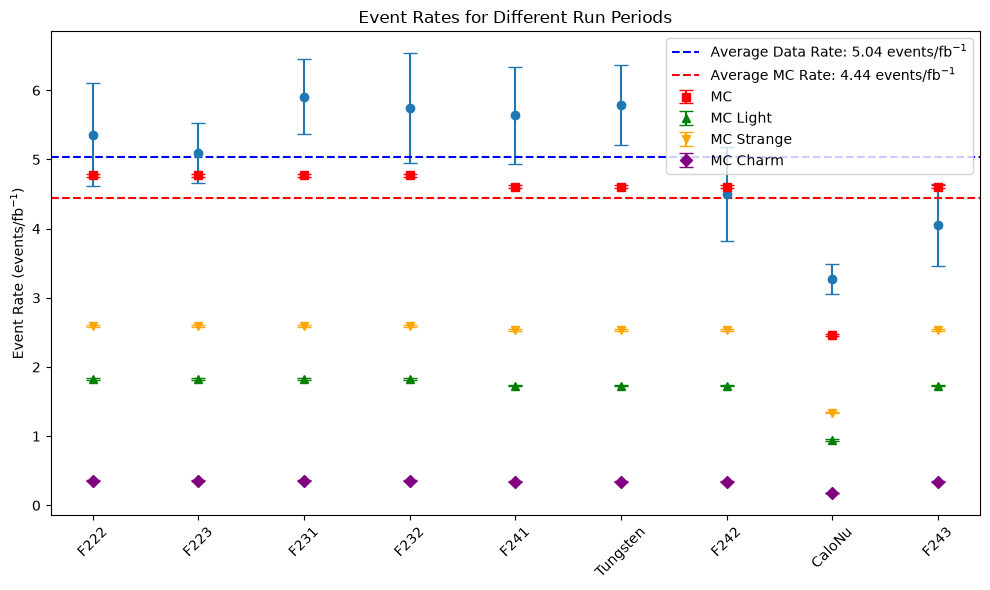

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(
    ["F222", "F223", "F231", "F232", "F241", "Tungsten", "F242", "CaloNu", "F243"],
    [rate[0] for rate in [rate_F222, rate_F223, rate_F231, rate_F232, rate_F241, rate_tungsten, rate_F242, rate_caloNu, rate_F243]],
    yerr=[rate[1] for rate in [rate_F222, rate_F223, rate_F231, rate_F232, rate_F241, rate_tungsten, rate_F242, rate_caloNu, rate_F243]],
    fmt='o', capsize=5
)

ax.errorbar(
    ["F222", "F223", "F231", "F232", "F241", "Tungsten", "F242", "CaloNu", "F243"],
    [rate[0] for rate in [rate_F222_MC, rate_F223_MC, rate_F231_MC, rate_F232_MC, rate_F241_MC, rate_tungsten_MC, rate_F242_MC, rate_caloNu_MC, rate_F243_MC]],
    yerr=[rate[1] for rate in [rate_F222_MC, rate_F223_MC, rate_F231_MC, rate_F232_MC, rate_F241_MC, rate_tungsten_MC, rate_F242_MC, rate_caloNu_MC, rate_F243_MC]],
    fmt='s', capsize=5, color='red', label='MC'
)

ax.errorbar(
    ["F222", "F223", "F231", "F232", "F241", "Tungsten", "F242", "CaloNu", "F243"],
    [rate[0] for rate in [rate_F222_light_MC, rate_F223_light_MC, rate_F231_light_MC, rate_F232_light_MC, rate_F241_light_MC, rate_tungsten_light_MC, rate_F242_light_MC, rate_caloNu_light_MC, rate_F243_light_MC]],
    yerr=[rate[1] for rate in [rate_F222_light_MC, rate_F223_light_MC, rate_F231_light_MC, rate_F232_light_MC, rate_F241_light_MC, rate_tungsten_light_MC, rate_F242_light_MC, rate_caloNu_light_MC, rate_F243_light_MC]],
    fmt='^', capsize=5, color='green', label='MC Light'
)

ax.errorbar(
    ["F222", "F223", "F231", "F232", "F241", "Tungsten", "F242", "CaloNu", "F243"],
    [rate[0] for rate in [rate_F222_strange_MC, rate_F223_strange_MC, rate_F231_strange_MC, rate_F232_strange_MC, rate_F241_strange_MC, rate_tungsten_strange_MC, rate_F242_strange_MC, rate_caloNu_strange_MC, rate_F243_strange_MC]],
    yerr=[rate[1] for rate in [rate_F222_strange_MC, rate_F223_strange_MC, rate_F231_strange_MC, rate_F232_strange_MC, rate_F241_strange_MC, rate_tungsten_strange_MC, rate_F242_strange_MC, rate_caloNu_strange_MC, rate_F243_strange_MC]],
    fmt='v', capsize=5, color='orange', label='MC Strange'
)

ax.errorbar(
    ["F222", "F223", "F231", "F232", "F241", "Tungsten", "F242", "CaloNu", "F243"],
    [rate[0] for rate in [rate_F222_charm_MC, rate_F223_charm_MC, rate_F231_charm_MC, rate_F232_charm_MC, rate_F241_charm_MC, rate_tungsten_charm_MC, rate_F242_charm_MC, rate_caloNu_charm_MC, rate_F243_charm_MC]],
    yerr=[rate[1] for rate in [rate_F222_charm_MC, rate_F223_charm_MC, rate_F231_charm_MC, rate_F232_charm_MC, rate_F241_charm_MC, rate_tungsten_charm_MC, rate_F242_charm_MC, rate_caloNu_charm_MC, rate_F243_charm_MC]],
    fmt='D', capsize=5, color='purple', label='MC Charm'
)


ax.set_ylabel("Event Rate (events/fb$^{-1}$)")
ax.set_title("Event Rates for Different Run Periods")

average_data_rate = np.mean([rate[0] for rate in [rate_F222, rate_F223, rate_F231, rate_F232, rate_F241, rate_tungsten, rate_F242, rate_caloNu, rate_F243]])
average_mc_rate = np.mean([rate[0] for rate in [rate_F222_MC, rate_F223_MC, rate_F231_MC, rate_F232_MC, rate_F241_MC, rate_tungsten_MC, rate_F242_MC, rate_caloNu_MC, rate_F243_MC]])
ax.axhline(average_data_rate, color='blue', linestyle='--', label=f'Average Data Rate: {average_data_rate:.2f}' + r' events/fb$^{-1}$')
ax.axhline(average_mc_rate, color='red', linestyle='--', label=f'Average MC Rate: {average_mc_rate:.2f}'+ r' events/fb$^{-1}$')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()

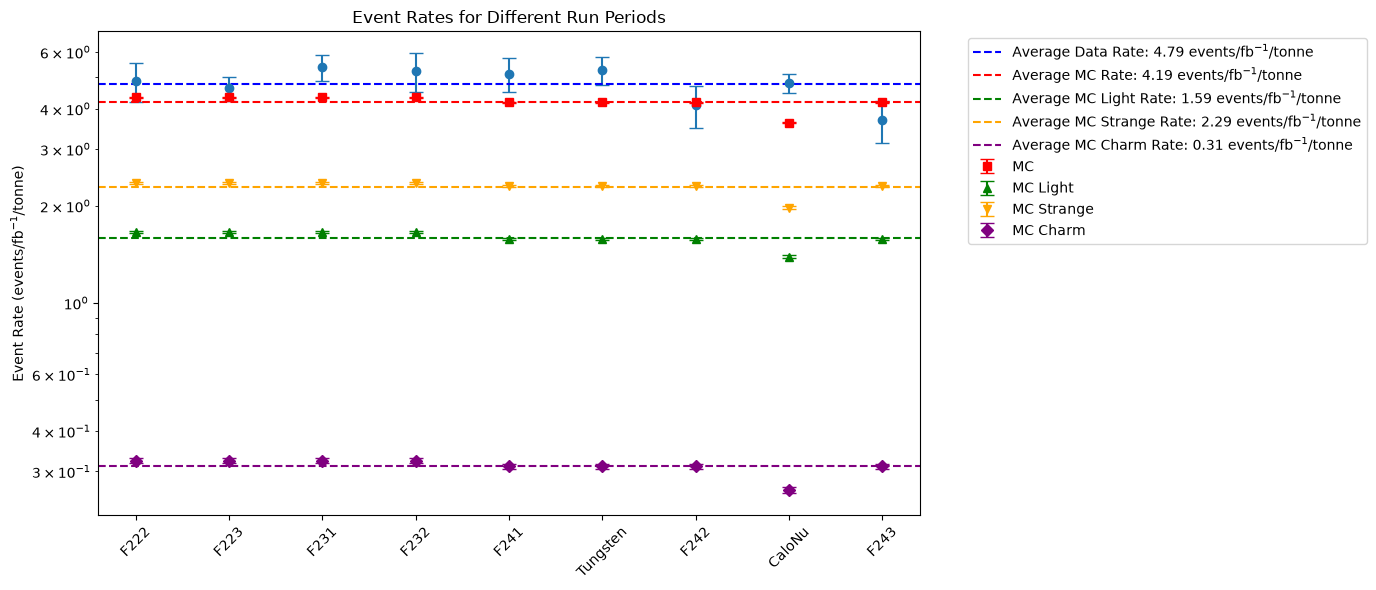

In [19]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.errorbar(
    ["F222", "F223", "F231", "F232", "F241", "Tungsten", "F242", "CaloNu", "F243"],
    [rate[0] for rate in [rate_per_kg_F222, rate_per_kg_F223, rate_per_kg_F231, rate_per_kg_F232, rate_per_kg_F241, rate_per_kg_tungsten, rate_per_kg_F242, rate_per_kg_caloNu, rate_per_kg_F243]],
    yerr=[rate[1] for rate in [rate_per_kg_F222, rate_per_kg_F223, rate_per_kg_F231, rate_per_kg_F232, rate_per_kg_F241, rate_per_kg_tungsten, rate_per_kg_F242, rate_per_kg_caloNu, rate_per_kg_F243]],
    fmt='o', capsize=5
)

ax.errorbar(
    ["F222", "F223", "F231", "F232", "F241", "Tungsten", "F242", "CaloNu", "F243"],
    [rate[0] for rate in [rate_per_kg_F222_MC, rate_per_kg_F223_MC, rate_per_kg_F231_MC, rate_per_kg_F232_MC, rate_per_kg_F241_MC, rate_per_kg_tungsten_MC, rate_per_kg_F242_MC, rate_per_kg_caloNu_MC, rate_per_kg_F243_MC]],
    yerr=[rate[1] for rate in [rate_per_kg_F222_MC, rate_per_kg_F223_MC, rate_per_kg_F231_MC, rate_per_kg_F232_MC, rate_per_kg_F241_MC, rate_per_kg_tungsten_MC, rate_per_kg_F242_MC, rate_per_kg_caloNu_MC, rate_per_kg_F243_MC]],
    fmt='s', capsize=5, color='red', label='MC'
)

ax.errorbar(
    ["F222", "F223", "F231", "F232", "F241", "Tungsten", "F242", "CaloNu", "F243"],
    [rate[0] for rate in [rate_per_kg_F222_light_MC, rate_per_kg_F223_light_MC, rate_per_kg_F231_light_MC, rate_per_kg_F232_light_MC, rate_per_kg_F241_light_MC, rate_per_kg_tungsten_light_MC, rate_per_kg_F242_light_MC, rate_per_kg_caloNu_light_MC, rate_per_kg_F243_light_MC]],
    yerr=[rate[1] for rate in [rate_per_kg_F222_light_MC, rate_per_kg_F223_light_MC, rate_per_kg_F231_light_MC, rate_per_kg_F232_light_MC, rate_per_kg_F241_light_MC, rate_per_kg_tungsten_light_MC, rate_per_kg_F242_light_MC, rate_per_kg_caloNu_light_MC, rate_per_kg_F243_light_MC]],
    fmt='^', capsize=5, color='green', label='MC Light'
)

ax.errorbar(
    ["F222", "F223", "F231", "F232", "F241", "Tungsten", "F242", "CaloNu", "F243"],
    [rate[0] for rate in [rate_per_kg_F222_strange_MC, rate_per_kg_F223_strange_MC, rate_per_kg_F231_strange_MC, rate_per_kg_F232_strange_MC, rate_per_kg_F241_strange_MC, rate_per_kg_tungsten_strange_MC, rate_per_kg_F242_strange_MC, rate_per_kg_caloNu_strange_MC, rate_per_kg_F243_strange_MC]],
    yerr=[rate[1] for rate in [rate_per_kg_F222_strange_MC, rate_per_kg_F223_strange_MC, rate_per_kg_F231_strange_MC, rate_per_kg_F232_strange_MC, rate_per_kg_F241_strange_MC, rate_per_kg_tungsten_strange_MC, rate_per_kg_F242_strange_MC, rate_per_kg_caloNu_strange_MC, rate_per_kg_F243_strange_MC]],
    fmt='v', capsize=5, color='orange', label='MC Strange'
)

ax.errorbar(
    ["F222", "F223", "F231", "F232", "F241", "Tungsten", "F242", "CaloNu", "F243"],
    [rate[0] for rate in [rate_per_kg_F222_charm_MC, rate_per_kg_F223_charm_MC, rate_per_kg_F231_charm_MC, rate_per_kg_F232_charm_MC, rate_per_kg_F241_charm_MC, rate_per_kg_tungsten_charm_MC, rate_per_kg_F242_charm_MC, rate_per_kg_caloNu_charm_MC, rate_per_kg_F243_charm_MC]],
    yerr=[rate[1] for rate in [rate_per_kg_F222_charm_MC, rate_per_kg_F223_charm_MC, rate_per_kg_F231_charm_MC, rate_per_kg_F232_charm_MC, rate_per_kg_F241_charm_MC, rate_per_kg_tungsten_charm_MC, rate_per_kg_F242_charm_MC, rate_per_kg_caloNu_charm_MC, rate_per_kg_F243_charm_MC]],
    fmt='D', capsize=5, color='purple', label='MC Charm'
)


ax.set_ylabel("Event Rate (events/fb$^{-1}$/tonne)")
ax.set_title("Event Rates for Different Run Periods")

average_data_rate = np.mean([rate[0] for rate in [rate_per_kg_F222, rate_per_kg_F223, rate_per_kg_F231, rate_per_kg_F232, rate_per_kg_F241, rate_per_kg_tungsten, rate_per_kg_F242, rate_per_kg_caloNu, rate_per_kg_F243]])
average_mc_rate = np.mean([rate[0] for rate in [rate_per_kg_F222_MC, rate_per_kg_F223_MC, rate_per_kg_F231_MC, rate_per_kg_F232_MC, rate_per_kg_F241_MC, rate_per_kg_tungsten_MC, rate_per_kg_F242_MC, rate_per_kg_caloNu_MC, rate_per_kg_F243_MC]])

average_mc_light_rate = np.mean([rate[0] for rate in [rate_per_kg_F222_light_MC, rate_per_kg_F223_light_MC, rate_per_kg_F231_light_MC, rate_per_kg_F232_light_MC, rate_per_kg_F241_light_MC, rate_per_kg_tungsten_light_MC, rate_per_kg_F242_light_MC, rate_per_kg_caloNu_light_MC, rate_per_kg_F243_light_MC]])
average_mc_strange_rate = np.mean([rate[0] for rate in [rate_per_kg_F222_strange_MC, rate_per_kg_F223_strange_MC, rate_per_kg_F231_strange_MC, rate_per_kg_F232_strange_MC, rate_per_kg_F241_strange_MC, rate_per_kg_tungsten_strange_MC, rate_per_kg_F242_strange_MC, rate_per_kg_caloNu_strange_MC, rate_per_kg_F243_strange_MC]])
average_mc_charm_rate = np.mean([rate[0] for rate in [rate_per_kg_F222_charm_MC, rate_per_kg_F223_charm_MC, rate_per_kg_F231_charm_MC, rate_per_kg_F232_charm_MC, rate_per_kg_F241_charm_MC, rate_per_kg_tungsten_charm_MC, rate_per_kg_F242_charm_MC, rate_per_kg_caloNu_charm_MC, rate_per_kg_F243_charm_MC]])


ax.axhline(average_data_rate, color='blue', linestyle='--', label=f'Average Data Rate: {average_data_rate:.2f}' + r' events/fb$^{-1}$/tonne')
ax.axhline(average_mc_rate, color='red', linestyle='--', label=f'Average MC Rate: {average_mc_rate:.2f}'+ r' events/fb$^{-1}$/tonne')
ax.axhline(average_mc_light_rate, color='green', linestyle='--', label=f'Average MC Light Rate: {average_mc_light_rate:.2f}'+ r' events/fb$^{-1}$/tonne')
ax.axhline(average_mc_strange_rate, color='orange', linestyle='--', label=f'Average MC Strange Rate: {average_mc_strange_rate:.2f}'+ r' events/fb$^{-1}$/tonne')
ax.axhline(average_mc_charm_rate, color='purple', linestyle='--', label=f'Average MC Charm Rate: {average_mc_charm_rate:.2f}'+ r' events/fb$^{-1}$/tonne')


ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
ax.set_yscale('log')
plt.tight_layout()